# Scalability Analysis

This notebook provides a **comprehensive benchmark analysis** of `sctrial` on a real longitudinal immunotherapy dataset (Sade‑Feldman et al., Cell 2018; GSE120575).

## Benchmark Objectives

To answer the following questions:

1. How does runtime scale with dataset size (cells, genes, participants)?
2. How do different aggregation strategies and statistical approaches compare?
3. How much memory is used across key operations?
4. Do statistical outputs look well‑behaved and consistent?
5. Are results reproducible across repeated runs?


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in sqrt')
warnings.filterwarnings('ignore', category=UserWarning, message='Only \d+ clusters')

import time
import psutil
import gc
from functools import wraps
from typing import Callable, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scipy.sparse as sp
import sctrial as st
from statsmodels.stats.multitest import multipletests

pd.options.mode.chained_assignment = None
sc.settings.verbosity = 0

# =============================================================================
# CONFIGURATION
# =============================================================================
SEED = 42
np.random.seed(SEED)

# Analysis parameters
MIN_GENES_FOR_SCORE = 5
MIN_PAIRED_PER_ARM = 3
FDR_ALPHA = 0.25

# Benchmark parameters
MAX_CELLS_PER_PARTICIPANT_VISIT = 500
SCALING_GENE_COUNTS = [100, 500, 1000, 2000, 5000]  # Gene scaling test
SCALING_CELL_FRACTIONS = [0.25, 0.5, 0.75, 1.0]     # Cell scaling test
N_BENCHMARK_REPEATS = 3                              # Repeats for timing stability
PARALLEL_JOBS = 2  # Jobs for did_table_parallel benchmarking

# Storage for benchmark results
benchmark_results = {
    'timing': {},
    'memory': {},
    'scaling': [],
    'validation': {}
}

# =============================================================================
# BENCHMARK UTILITIES
# =============================================================================
def timed_run(func: Callable, *args, n_repeats: int = 1, **kwargs) -> tuple[Any, float, float]:
    """Run function with timing, return (result, mean_time, std_time)."""
    times = []
    result = None
    for _ in range(n_repeats):
        if result is not None:
            del result          # free prior iteration's result before next run
        gc.collect()
        start = time.perf_counter()
        result = func(*args, **kwargs)
        times.append(time.perf_counter() - start)
    return result, np.mean(times), np.std(times)

def memory_profile(func: Callable, *args, **kwargs) -> tuple[Any, float, float]:
    """Run function with memory profiling, return (result, delta_mb, current_mb).
    
    Measures process RSS (Resident Set Size) before and after the function call.
    RSS captures all allocations including C-level / numpy arrays, unlike
    tracemalloc which only tracks Python-level allocations and can report stale
    cumulative peaks across calls.
    """
    gc.collect()
    process = psutil.Process()
    rss_before = process.memory_info().rss
    result = func(*args, **kwargs)
    rss_after = process.memory_info().rss
    gc.collect()
    delta_mb = (rss_after - rss_before) / 1024 / 1024
    current_mb = rss_after / 1024 / 1024
    return result, max(delta_mb, 0), current_mb

def format_time(seconds: float) -> str:
    """Format seconds to human-readable string."""
    if seconds < 1:
        return f"{seconds*1000:.1f}ms"
    elif seconds < 60:
        return f"{seconds:.2f}s"
    else:
        return f"{seconds/60:.1f}min"

print("=" * 70)
print("SCTRIAL SCALABILITY BENCHMARK")
print("=" * 70)
print(f"sctrial version: {st.__version__}")
print(f"Random seed: {SEED}")
print(f"Benchmark repeats: {N_BENCHMARK_REPEATS}")

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/var/folders/71/dc4p4yz15s74z9c69xy6sk_00000gt/T/ipykernel_68992/1555409914.py:5: SyntaxWarning: invalid escape sequence '\d'
  warnings.filterwarnings('ignore', category=UserWarning, message='Only \d+ clusters')


SCTRIAL SCALABILITY BENCHMARK
sctrial version: 0.2.1.dev1
Random seed: 42
Benchmark repeats: 3


---
## 1. Setup & Data Loading

Load the Sade-Feldman melanoma immunotherapy dataset and establish the trial design.

In [2]:
from sctrial.datasets import load_sade_feldman

# Load with memory profiling
print("Loading dataset...")
(adata, load_time, _) = timed_run(
    load_sade_feldman,
    max_cells_per_participant_visit=MAX_CELLS_PER_PARTICIPANT_VISIT,
    processed_name="sade_feldman_processed_v5_subsample.h5ad",
    allow_download=True,
    n_repeats=1
)
benchmark_results['timing']['data_load'] = load_time
print(f"  Load time: {format_time(load_time)}")

Loading dataset...


  Load time: 653.1ms


### Data Harmonization & Trial Design Setup

In [3]:
# =============================================================================
# RESPONSE HARMONIZATION
# =============================================================================
# Harmonize response labels at participant level (majority label for mixed cases)
resp_counts = (
    adata.obs
    .groupby(["participant_id", "response"], observed=True)
    .size()
    .reset_index(name="n_cells")
)
resp_n = resp_counts.groupby("participant_id")["response"].nunique()
mixed_ids = resp_n[resp_n > 1].index.tolist()

dominant_response = (
    resp_counts
    .sort_values(["participant_id", "n_cells"], ascending=[True, False])
    .drop_duplicates("participant_id")
    .set_index("participant_id")["response"]
)

RESPONSE_COL = "response_harmonized"
adata.obs[RESPONSE_COL] = adata.obs["participant_id"].map(dominant_response)

# =============================================================================
# IDENTIFY PAIRED PARTICIPANTS
# =============================================================================
visit_col = "visit"
adata.obs[visit_col] = adata.obs[visit_col].astype(str)
visits = [v for v in ["Pre", "Post"] if v in adata.obs[visit_col].unique()]

participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_Pre"] = participant_summary[visit_col].apply(lambda x: "Pre" in x)
participant_summary["has_Post"] = participant_summary[visit_col].apply(lambda x: "Post" in x)
participant_summary["is_paired"] = participant_summary["has_Pre"] & participant_summary["has_Post"]
participant_summary[RESPONSE_COL] = participant_summary["participant_id"].map(dominant_response)

paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])
paired_by_response = (
    participant_summary[participant_summary["is_paired"]]
    .groupby(RESPONSE_COL)
    .size()
    .to_dict()
)

# Subset to paired participants
adata_paired = adata[adata.obs["participant_id"].isin(paired_ids)].copy()

# =============================================================================
# TRIAL DESIGN
# =============================================================================
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col=RESPONSE_COL,
    arm_treated="Responder",
    arm_control="Non-responder",
    celltype_col="cell_type",
)

# Store dataset info for benchmarks
dataset_info = {
    'n_cells_full': adata.n_obs,
    'n_cells_paired': adata_paired.n_obs,
    'n_genes': adata.n_vars,
    'n_participants_full': adata.obs['participant_id'].nunique(),
    'n_participants_paired': len(paired_ids),
    'n_paired_responder': paired_by_response.get('Responder', 0),
    'n_paired_nonresponder': paired_by_response.get('Non-responder', 0),
}

benchmark_results['dataset_info'] = dataset_info

---
## 2. Dataset Overview

Here, we summarize the dataset characteristics and **benchmark configuration** in tables, then visualize key distributions to ground the benchmarking context.


DATASET SUMMARY


Metric,Value
Full Dataset - Cells,"12,187"
Full Dataset - Genes,"55,737"
Full Dataset - Participants,25
Paired Dataset - Cells,"7,068"
Paired Dataset - Participants,10
Responders (paired),3
Non-responders (paired),7
Visits,"['Pre', 'Post']"
Mixed-response participants,3



BENCHMARK CONFIGURATION
--------------------------------------------------


Parameter,Value
Scaling gene counts,"[100, 500, 1000, 2000, 5000]"
Cell fractions,"[0.25, 0.5, 0.75, 1.0]"
Repeats per test,3
Min genes for scoring,5
Min paired per arm,3
FDR threshold,0.25
Max cells/participant‑visit,500


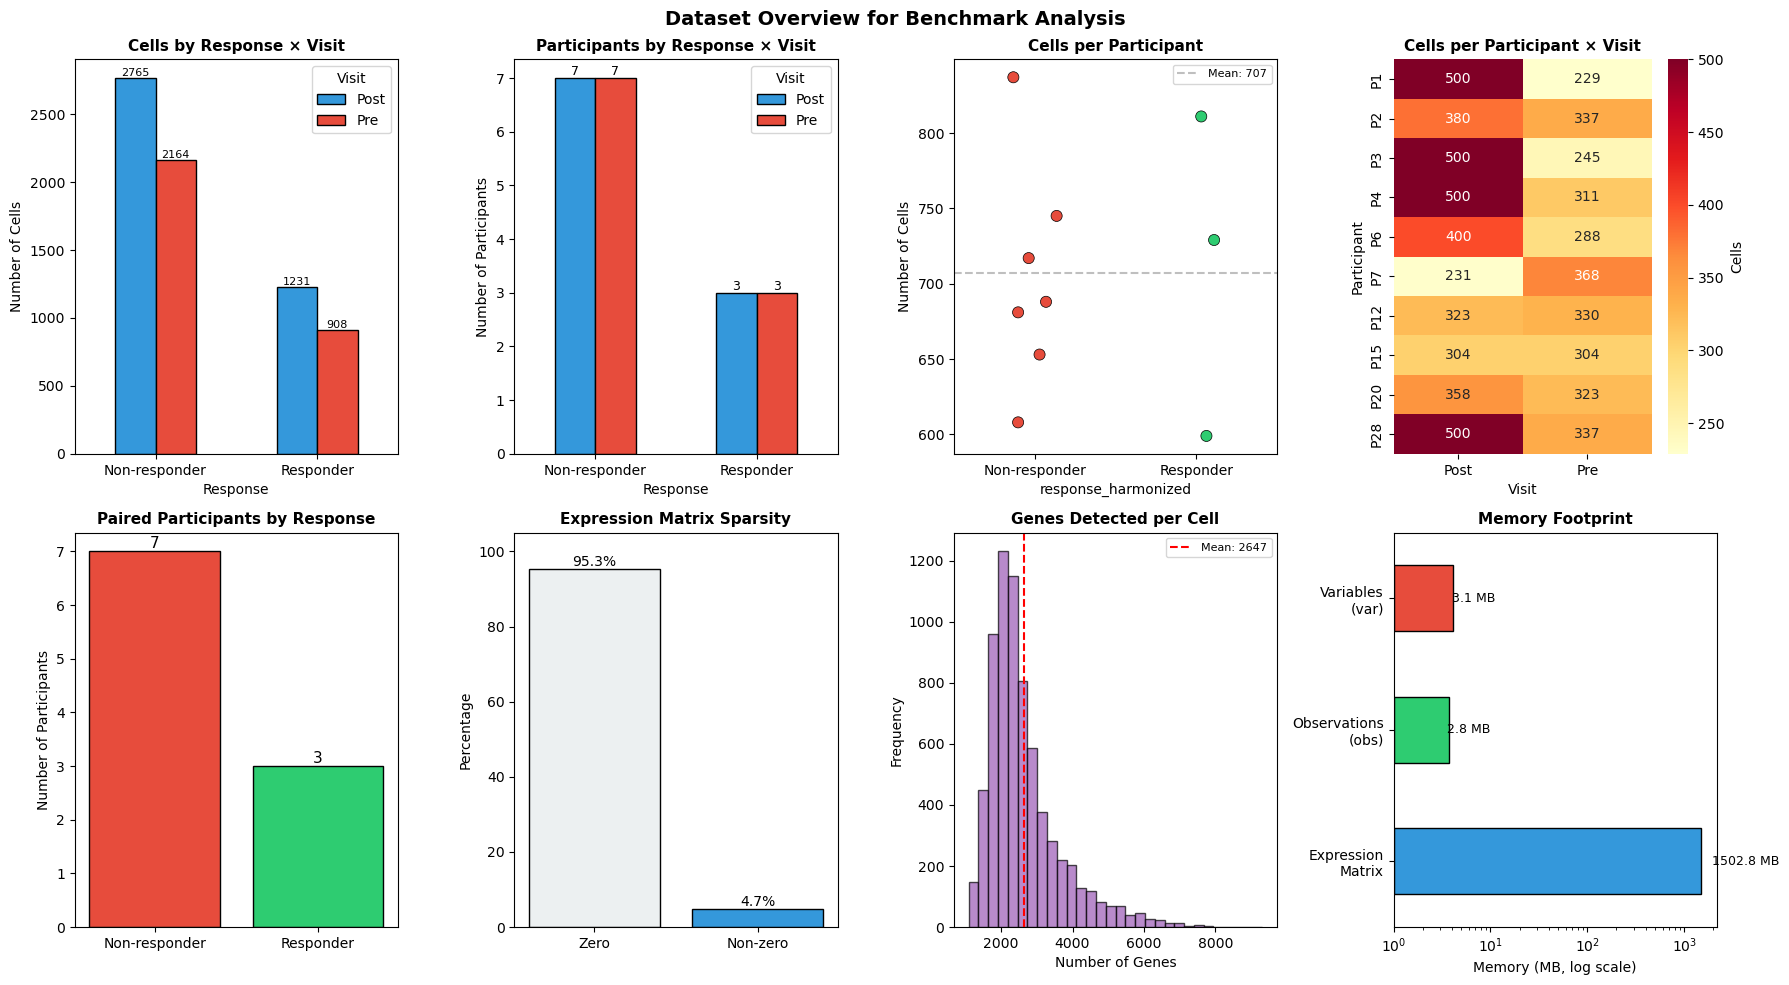


Total estimated memory: 1508.6 MB


In [4]:
# =============================================================================
# DATASET SUMMARY TABLE
# =============================================================================
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame([
    ("Full Dataset - Cells", f"{dataset_info['n_cells_full']:,}"),
    ("Full Dataset - Genes", f"{dataset_info['n_genes']:,}"),
    ("Full Dataset - Participants", f"{dataset_info['n_participants_full']}"),
    ("Paired Dataset - Cells", f"{dataset_info['n_cells_paired']:,}"),
    ("Paired Dataset - Participants", f"{dataset_info['n_participants_paired']}"),
    ("  Responders (paired)", f"{dataset_info['n_paired_responder']}"),
    ("  Non-responders (paired)", f"{dataset_info['n_paired_nonresponder']}"),
    ("Visits", f"{visits}"),
    ("Mixed-response participants", f"{len(mixed_ids)}"),
], columns=["Metric", "Value"])

display(summary_df.style.hide(axis='index'))

# =============================================================================
# BENCHMARK CONFIGURATION TABLE
# =============================================================================
config_df = pd.DataFrame([
    ("Scaling gene counts", f"{SCALING_GENE_COUNTS}"),
    ("Cell fractions", f"{SCALING_CELL_FRACTIONS}"),
    ("Repeats per test", f"{N_BENCHMARK_REPEATS}"),
    ("Min genes for scoring", f"{MIN_GENES_FOR_SCORE}"),
    ("Min paired per arm", f"{MIN_PAIRED_PER_ARM}"),
    ("FDR threshold", f"{FDR_ALPHA}"),
    ("Max cells/participant\u2011visit", f"{MAX_CELLS_PER_PARTICIPANT_VISIT}"),
], columns=["Parameter", "Value"])

print("\nBENCHMARK CONFIGURATION")
print("-" * 50)
display(config_df.style.hide(axis='index'))

# =============================================================================
# COMPREHENSIVE VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# 1. Cells per Response x Visit
ax1 = axes[0, 0]
cell_counts = adata_paired.obs.groupby([RESPONSE_COL, visit_col], observed=True).size().unstack(fill_value=0)
cell_counts.plot(kind="bar", ax=ax1, color=['#3498db', '#e74c3c'], edgecolor='black')
ax1.set_title("Cells by Response \u00d7 Visit", fontsize=11, fontweight='bold')
ax1.set_xlabel("Response")
ax1.set_ylabel("Number of Cells")
ax1.legend(title="Visit")
ax1.tick_params(axis='x', rotation=0)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=8)

# 2. Participants per Response x Visit
ax2 = axes[0, 1]
pt_counts = adata_paired.obs.groupby([RESPONSE_COL, visit_col], observed=True)["participant_id"].nunique().unstack(fill_value=0)
pt_counts.plot(kind="bar", ax=ax2, color=['#3498db', '#e74c3c'], edgecolor='black')
ax2.set_title("Participants by Response \u00d7 Visit", fontsize=11, fontweight='bold')
ax2.set_xlabel("Response")
ax2.set_ylabel("Number of Participants")
ax2.legend(title="Visit")
ax2.tick_params(axis='x', rotation=0)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', fontsize=9)

# 3. Cells per Participant (strip plot — better than histogram for n=10)
ax3 = axes[0, 2]
cells_per_pt = adata_paired.obs.groupby("participant_id").size().reset_index(name="n_cells")
cells_per_pt[RESPONSE_COL] = cells_per_pt["participant_id"].map(
    adata_paired.obs.groupby("participant_id")[RESPONSE_COL].first()
)
sns.stripplot(data=cells_per_pt, x=RESPONSE_COL, y="n_cells", ax=ax3,
              palette={'Responder': '#2ecc71', 'Non-responder': '#e74c3c'},
              size=8, jitter=0.15, edgecolor='black', linewidth=0.5)
ax3.axhline(cells_per_pt["n_cells"].mean(), color='gray', linestyle='--', alpha=0.5,
            label=f'Mean: {cells_per_pt["n_cells"].mean():.0f}')
ax3.set_title("Cells per Participant", fontsize=11, fontweight='bold')
ax3.set_ylabel("Number of Cells")
ax3.legend(fontsize=8)

# 4. Cells per Participant-Visit Heatmap
ax4 = axes[0, 3]
cells_pv = adata_paired.obs.groupby(["participant_id", visit_col], observed=True).size().unstack(fill_value=0)
sns.heatmap(cells_pv, annot=True, fmt='d', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Cells'})
ax4.set_title("Cells per Participant \u00d7 Visit", fontsize=11, fontweight='bold')
ax4.set_xlabel("Visit")
ax4.set_ylabel("Participant")

# 5. Response Balance
ax5 = axes[1, 0]
response_counts = pd.Series(paired_by_response)
colors = ['#e74c3c' if x == 'Non-responder' else '#2ecc71' for x in response_counts.index]
bars = ax5.bar(response_counts.index, response_counts.values, color=colors, edgecolor='black')
ax5.set_title("Paired Participants by Response", fontsize=11, fontweight='bold')
ax5.set_ylabel("Number of Participants")
ax5.bar_label(bars, fmt='%d', fontsize=11)

# 6. Data Sparsity (bar instead of pie — cleaner for 2-category)
ax6 = axes[1, 1]
if sp.issparse(adata_paired.X):
    sparsity = 1.0 - (adata_paired.X.nnz / (adata_paired.X.shape[0] * adata_paired.X.shape[1]))
else:
    sparsity = np.mean(adata_paired.X == 0)
bar_sp = ax6.bar(["Zero", "Non-zero"], [sparsity * 100, (1 - sparsity) * 100],
                 color=['#ecf0f1', '#3498db'], edgecolor='black')
ax6.bar_label(bar_sp, fmt='%.1f%%', fontsize=10)
ax6.set_ylabel("Percentage")
ax6.set_title(f"Expression Matrix Sparsity", fontsize=11, fontweight='bold')
ax6.set_ylim(0, 105)

# 7. Gene Detection per Cell
ax7 = axes[1, 2]
if sp.issparse(adata_paired.X):
    genes_per_cell = np.array((adata_paired.X > 0).sum(axis=1)).flatten()
else:
    genes_per_cell = np.sum(adata_paired.X > 0, axis=1)
ax7.hist(genes_per_cell, bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
ax7.axvline(np.mean(genes_per_cell), color='red', linestyle='--', label=f'Mean: {np.mean(genes_per_cell):.0f}')
ax7.set_title("Genes Detected per Cell", fontsize=11, fontweight='bold')
ax7.set_xlabel("Number of Genes")
ax7.set_ylabel("Frequency")
ax7.legend(fontsize=8)

# 8. Memory Footprint (log scale for readability)
ax8 = axes[1, 3]
if sp.issparse(adata_paired.X):
    matrix_mb = adata_paired.X.data.nbytes / 1024 / 1024
else:
    matrix_mb = adata_paired.X.nbytes / 1024 / 1024
obs_mb = adata_paired.obs.memory_usage(deep=True).sum() / 1024 / 1024
var_mb = adata_paired.var.memory_usage(deep=True).sum() / 1024 / 1024

mem_data = pd.Series({'Expression\nMatrix': matrix_mb, 'Observations\n(obs)': obs_mb, 'Variables\n(var)': var_mb})
mem_data.plot(kind='barh', ax=ax8, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', log=True)
ax8.set_title("Memory Footprint", fontsize=11, fontweight='bold')
ax8.set_xlabel("Memory (MB, log scale)")
for i, v in enumerate(mem_data):
    ax8.text(v * 1.3, i, f'{v:.1f} MB', va='center', fontsize=9)

plt.suptitle("Dataset Overview for Benchmark Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal estimated memory: {matrix_mb + obs_mb + var_mb:.1f} MB")


---
## 3. Gene Signature Scoring

Score biologically relevant gene signatures for downstream analysis.

Signature Gene Coverage:
--------------------------------------------------


Signature,Found,Total,Coverage,Status
Cytotoxicity,11,11,100%,OK
Exhaustion,9,9,100%,OK
IFN_Response,10,10,100%,OK
Memory,7,7,100%,OK
Activation,6,6,100%,OK



Signature scoring time: 9.9ms ± 2.1ms
Signatures scored: 5


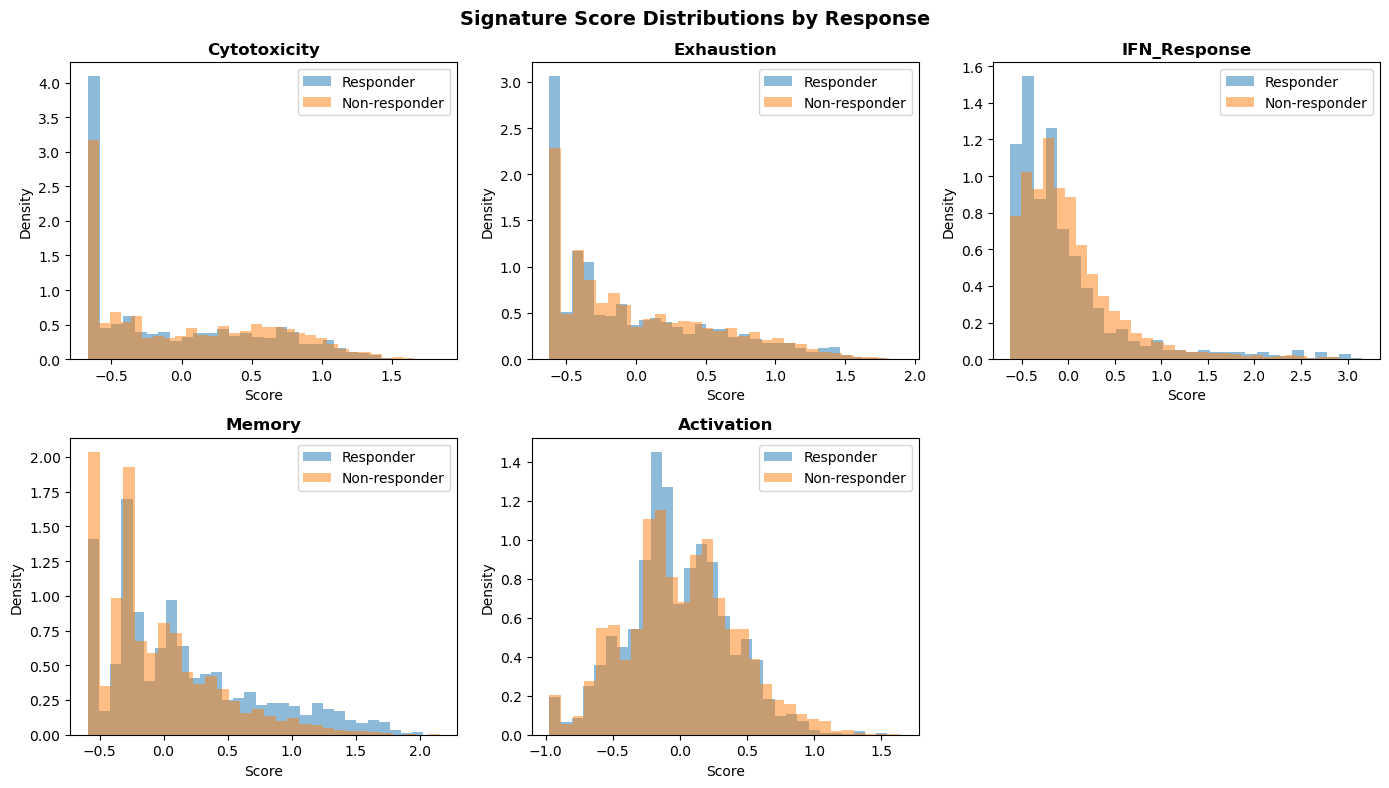

In [5]:
# =============================================================================
# DEFINE GENE SIGNATURES
# =============================================================================
available = set(adata_paired.var_names)

raw_signatures = {
    "Cytotoxicity": ["GZMB", "GZMA", "GZMH", "GZMK", "PRF1", "GNLY", "IFNG", "NKG7", "KLRD1", "KLRB1", "FASLG"],
    "Exhaustion": ["PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4", "TOX", "ENTPD1", "CXCL13", "EOMES"],
    "IFN_Response": ["ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "MX2", "STAT1", "OAS1", "IRF7"],
    "Memory": ["IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28"],
    "Activation": ["CD69", "CD38", "HLA-DRA", "ICOS", "CD44", "IL2RA"],
}

# Filter signatures by gene availability
print("Signature Gene Coverage:")
print("-" * 50)
filtered_signatures = {}
coverage_data = []
for name, genes in raw_signatures.items():
    found = [g for g in genes if g in available]
    pct = len(found) / len(genes) * 100
    status = "OK" if len(found) >= MIN_GENES_FOR_SCORE else "SKIP"
    coverage_data.append({
        'Signature': name, 
        'Found': len(found), 
        'Total': len(genes), 
        'Coverage': f"{pct:.0f}%",
        'Status': status
    })
    if len(found) >= MIN_GENES_FOR_SCORE:
        filtered_signatures[name] = found

coverage_df = pd.DataFrame(coverage_data)
display(coverage_df.style.hide(axis='index'))

# =============================================================================
# SCORE SIGNATURES WITH TIMING
# =============================================================================
if filtered_signatures:
    def score_signatures():
        return st.score_gene_sets(
            adata_paired,
            filtered_signatures,
            layer="log1p_tpm",
            method="zmean",
            prefix="sig_",
        )
    
    _, score_time, score_std = timed_run(score_signatures, n_repeats=N_BENCHMARK_REPEATS)
    benchmark_results['timing']['signature_scoring'] = score_time
    
    print(f"\nSignature scoring time: {format_time(score_time)} ± {format_time(score_std)}")
    print(f"Signatures scored: {len(filtered_signatures)}")

signature_cols = [c for c in adata_paired.obs.columns if c.startswith("sig_")]

# Visualize signature distributions
if signature_cols:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(signature_cols[:6]):
        ax = axes[i]
        for response in adata_paired.obs[RESPONSE_COL].unique():
            mask = adata_paired.obs[RESPONSE_COL] == response
            data = adata_paired.obs.loc[mask, col].dropna()
            ax.hist(data, bins=30, alpha=0.5, label=response, density=True)
        ax.set_title(col.replace('sig_', ''), fontweight='bold')
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend()
    
    # Hide unused axes
    for j in range(len(signature_cols), 6):
        axes[j].axis('off')
    
    plt.suptitle("Signature Score Distributions by Response", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [6]:
# =============================================================================
# PAIRING VERIFICATION
# =============================================================================
print("Pairing Verification")
print("-" * 50)

if signature_cols:
    df_pv = (
        adata_paired.obs
        .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[signature_cols]
        .mean()
        .reset_index()
    )
    
    valid_paired = {}
    for feat in signature_cols:
        wide = df_pv.pivot(index=design.participant_col, columns=design.visit_col, values=feat)
        if visits[0] in wide.columns and visits[1] in wide.columns:
            mask = wide[visits[0]].notna() & wide[visits[1]].notna()
            valid_paired[feat] = set(wide[mask].index)
        else:
            valid_paired[feat] = set()
    
    all_features_valid = set.intersection(*[valid_paired[f] for f in signature_cols]) if signature_cols else set()
    participant_arm = adata_paired.obs.groupby(design.participant_col)[design.arm_col].first()
    
    VALID_PAIRED_BY_RESPONSE = {
        arm: {pid for pid in all_features_valid if participant_arm.get(pid) == arm}
        for arm in [design.arm_treated, design.arm_control]
    }
    N_VALID_PAIRED = len(all_features_valid)
    
    print(f"Participants with valid Pre+Post scores: {N_VALID_PAIRED}")
    print(f"  {design.arm_treated}: {len(VALID_PAIRED_BY_RESPONSE[design.arm_treated])}")
    print(f"  {design.arm_control}: {len(VALID_PAIRED_BY_RESPONSE[design.arm_control])}")
else:
    VALID_PAIRED_BY_RESPONSE = paired_by_response
    N_VALID_PAIRED = len(paired_ids)

Pairing Verification
--------------------------------------------------
Participants with valid Pre+Post scores: 10
  Responder: 3
  Non-responder: 7


---
## 4. Scaling Benchmarks

Here, we benchmark how `sctrial` scales with dataset size. We vary **gene counts** and **cell fractions** to stress‑test performance.

- **Cell fractions** refer to keeping a fixed proportion of cells (e.g., 25%, 50%, 75%, 100%) via stratified subsampling **within each participant‑visit**, preserving pairing and structure.
- **Method comparison** evaluates the same study design (Responder vs Non‑responder; Pre vs Post) under different aggregation and analysis strategies.


GENE SCALING BENCHMARK
Testing DiD performance across 5 gene counts...


  100 genes: serial 730.0ms ± 3.5ms (137 genes/sec) | parallel 1.39s ± 1.04s (72 genes/sec)


  500 genes: serial 1.60s ± 16.3ms (313 genes/sec) | parallel 1.16s ± 22.5ms (432 genes/sec)


  1,000 genes: serial 2.71s ± 123.3ms (369 genes/sec) | parallel 1.68s ± 24.6ms (595 genes/sec)


  2,000 genes: serial 5.06s ± 128.6ms (395 genes/sec) | parallel 2.88s ± 50.4ms (693 genes/sec)


  5,000 genes: serial 10.79s ± 78.9ms (463 genes/sec) | parallel 6.67s ± 168.7ms (750 genes/sec)

CELL SCALING BENCHMARK
Testing DiD performance across 4 cell fractions...
Cell fractions keep a fixed proportion of cells per participant-visit (stratified), preserving pairing.


  25% (1,767 cells): 1.20s ± 16.9ms


  50% (3,534 cells): 1.38s ± 10.9ms


  75% (5,301 cells): 1.57s ± 45.1ms


  100% (7,068 cells): 1.66s ± 46.4ms


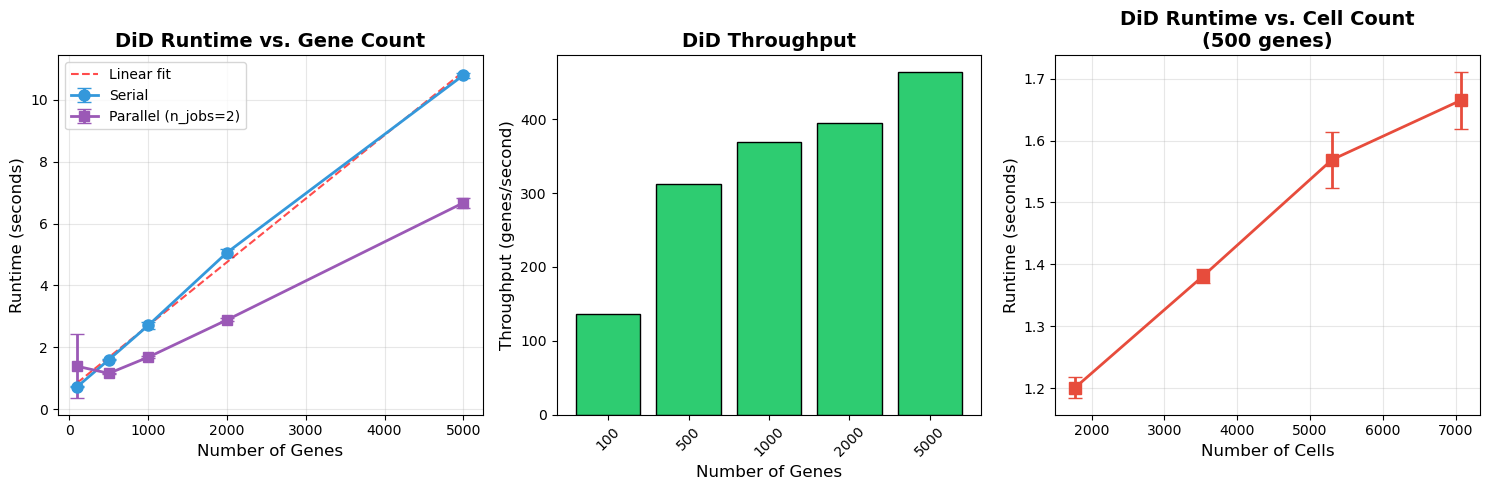

In [7]:
# =============================================================================
# SCALING BENCHMARK: Genes
# =============================================================================
print("=" * 70)
print("GENE SCALING BENCHMARK")
print("=" * 70)
print(f"Testing DiD performance across {len(SCALING_GENE_COUNTS)} gene counts...")

gene_scaling_results = []

for n_genes in SCALING_GENE_COUNTS:
    if n_genes > adata_paired.n_vars:
        print(f"  Skipping {n_genes} genes (exceeds available {adata_paired.n_vars})")
        continue
    
    # Select genes
    _test_genes = list(adata_paired.var_names[:n_genes])
    
    # Benchmark DiD (serial) — capture loop variable via default arg
    def run_did(genes=_test_genes):
        return st.did_table(
            adata_paired,
            features=genes,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            layer="log1p_tpm",
        )
    
    # Benchmark DiD (parallel)
    def run_did_parallel(genes=_test_genes):
        return st.did_table_parallel(
            adata_paired,
            features=genes,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            layer="log1p_tpm",
            n_jobs=PARALLEL_JOBS,
        )
    
    _, mean_time, std_time = timed_run(run_did, n_repeats=N_BENCHMARK_REPEATS)
    _, mean_time_par, std_time_par = timed_run(run_did_parallel, n_repeats=N_BENCHMARK_REPEATS)
    
    gene_scaling_results.append({
        'n_genes': n_genes,
        'mean_time': mean_time,
        'std_time': std_time,
        'genes_per_sec': n_genes / mean_time,
        'mean_time_parallel': mean_time_par,
        'std_time_parallel': std_time_par,
        'genes_per_sec_parallel': n_genes / mean_time_par,
    })
    
    print(f"  {n_genes:,} genes: serial {format_time(mean_time)} ± {format_time(std_time)} "
          f"({n_genes/mean_time:.0f} genes/sec) | parallel {format_time(mean_time_par)} ± {format_time(std_time_par)} "
          f"({n_genes/mean_time_par:.0f} genes/sec)")
    
    # Free intermediate results between iterations to limit memory growth
    del _test_genes
    gc.collect()

gene_scaling_df = pd.DataFrame(gene_scaling_results)
benchmark_results['scaling'].append(('genes', gene_scaling_df))

# =============================================================================
# SCALING BENCHMARK: Cells
# =============================================================================
print("\n" + "=" * 70)
print("CELL SCALING BENCHMARK")
print("=" * 70)
print(f"Testing DiD performance across {len(SCALING_CELL_FRACTIONS)} cell fractions...")
print("Cell fractions keep a fixed proportion of cells per participant-visit (stratified), preserving pairing.")

cell_scaling_results = []
n_test_genes = 500  # Fixed gene count for cell scaling test

for frac in SCALING_CELL_FRACTIONS:
    n_cells = int(adata_paired.n_obs * frac)
    
    # Subsample cells (stratified by participant-visit)
    if frac < 1.0:
        sampled_idx = (
            adata_paired.obs
            .groupby([design.participant_col, design.visit_col], observed=True)
            .apply(lambda x: x.sample(frac=frac, random_state=SEED) if len(x) > 1 else x)
            .index.get_level_values(-1)
        )
        adata_sub = adata_paired[sampled_idx].copy()
    else:
        adata_sub = adata_paired
    
    _test_genes_cell = list(adata_sub.var_names[:n_test_genes])
    
    # Capture loop variables via default args
    def run_did_cells(ad=adata_sub, genes=_test_genes_cell):
        return st.did_table(
            ad,
            features=genes,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            layer="log1p_tpm",
        )
    
    _, mean_time, std_time = timed_run(run_did_cells, n_repeats=N_BENCHMARK_REPEATS)
    
    cell_scaling_results.append({
        'cell_fraction': frac,
        'n_cells': adata_sub.n_obs,
        'mean_time': mean_time,
        'std_time': std_time,
    })
    
    print(f"  {frac*100:.0f}% ({adata_sub.n_obs:,} cells): {format_time(mean_time)} ± {format_time(std_time)}")
    
    # Free subsampled AnnData between iterations
    if frac < 1.0:
        del adata_sub, sampled_idx
    del _test_genes_cell
    gc.collect()

cell_scaling_df = pd.DataFrame(cell_scaling_results)
benchmark_results['scaling'].append(('cells', cell_scaling_df))

# =============================================================================
# SCALING VISUALIZATION  (publication-quality 2x2 panel)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ---- Colour palette & common style ----
C_SERIAL   = '#2c7bb6'
C_PARALLEL = '#d7191c'
C_CELL     = '#fdae61'
C_THRU_S   = '#2c7bb6'
C_THRU_P   = '#d7191c'
MARKER_KW  = dict(markersize=7, markeredgecolor='black', markeredgewidth=0.6)

# ---- (a) Gene-scaling: log-log with error bands ----
ax = axes[0, 0]
x_g = gene_scaling_df['n_genes'].values
y_s = gene_scaling_df['mean_time'].values
e_s = gene_scaling_df['std_time'].values

ax.fill_between(x_g, y_s - e_s, y_s + e_s, color=C_SERIAL, alpha=0.15)
ax.plot(x_g, y_s, 'o-', color=C_SERIAL, linewidth=2, label='Serial', **MARKER_KW)

if 'mean_time_parallel' in gene_scaling_df.columns:
    y_p = gene_scaling_df['mean_time_parallel'].values
    e_p = gene_scaling_df['std_time_parallel'].values
    ax.fill_between(x_g, y_p - e_p, y_p + e_p, color=C_PARALLEL, alpha=0.15)
    ax.plot(x_g, y_p, 's--', color=C_PARALLEL, linewidth=2,
            label=f'Parallel (n_jobs={PARALLEL_JOBS})', **MARKER_KW)

# Log-log + linear-scaling reference line
ax.set_xscale('log'); ax.set_yscale('log')
x_ref = np.array([x_g.min(), x_g.max()])
scale = y_s[0] / x_g[0]
ax.plot(x_ref, x_ref * scale, ':', color='grey', alpha=0.6, label='O(n) reference')
ax.legend(fontsize=9, framealpha=0.9)
ax.set_xlabel('Number of Genes', fontsize=11)
ax.set_ylabel('Runtime (s)', fontsize=11)
ax.set_title('(a)  Gene Scaling (log-log)', fontsize=12, fontweight='bold')
ax.grid(True, which='both', alpha=0.2)

# ---- (b) Cell-scaling: log-log with error band ----
ax = axes[0, 1]
x_c = cell_scaling_df['n_cells'].values
y_c = cell_scaling_df['mean_time'].values
e_c = cell_scaling_df['std_time'].values

ax.fill_between(x_c, y_c - e_c, y_c + e_c, color=C_CELL, alpha=0.25)
ax.plot(x_c, y_c, 'D-', color=C_CELL, linewidth=2, label='500 genes', **MARKER_KW)

ax.set_xscale('log'); ax.set_yscale('log')
scale_c = y_c[0] / x_c[0]
ax.plot([x_c.min(), x_c.max()],
        [x_c.min() * scale_c, x_c.max() * scale_c],
        ':', color='grey', alpha=0.6, label='O(n) reference')
ax.legend(fontsize=9, framealpha=0.9)
ax.set_xlabel('Number of Cells', fontsize=11)
ax.set_ylabel('Runtime (s)', fontsize=11)
ax.set_title('(b)  Cell Scaling (log-log)', fontsize=12, fontweight='bold')
ax.grid(True, which='both', alpha=0.2)

# ---- (c) Throughput: serial vs parallel grouped lollipop ----
ax = axes[1, 0]
labels = gene_scaling_df['n_genes'].astype(str).values
y_pos = np.arange(len(labels))
width = 0.35

thru_s = gene_scaling_df['genes_per_sec'].values
ax.hlines(y_pos + width/2, 0, thru_s, color=C_THRU_S, linewidth=2)
ax.plot(thru_s, y_pos + width/2, 'o', color=C_THRU_S, markersize=8,
        markeredgecolor='black', markeredgewidth=0.6, label='Serial')

if 'genes_per_sec_parallel' in gene_scaling_df.columns:
    thru_p = gene_scaling_df['genes_per_sec_parallel'].values
    ax.hlines(y_pos - width/2, 0, thru_p, color=C_THRU_P, linewidth=2)
    ax.plot(thru_p, y_pos - width/2, 's', color=C_THRU_P, markersize=8,
            markeredgecolor='black', markeredgewidth=0.6, label='Parallel')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_ylabel('Number of Genes', fontsize=11)
ax.set_xlabel('Throughput (genes / s)', fontsize=11)
ax.set_title('(c)  Throughput', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, axis='x', alpha=0.2)

# ---- (d) Parallel speed-up factor ----
ax = axes[1, 1]
if 'mean_time_parallel' in gene_scaling_df.columns:
    speedup = gene_scaling_df['mean_time'] / gene_scaling_df['mean_time_parallel']
    ax.plot(x_g, speedup, 'o-', color='#756bb1', linewidth=2, **MARKER_KW)
    ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5, label='No speed-up')
    ax.axhline(PARALLEL_JOBS, color='#d7191c', linestyle=':', alpha=0.5,
               label=f'Ideal ({PARALLEL_JOBS}\u00d7)')
    ax.set_xscale('log')
    ax.set_xlabel('Number of Genes', fontsize=11)
    ax.set_ylabel('Speed-up (serial / parallel)', fontsize=11)
    ax.set_title('(d)  Parallel Speed-up', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, which='both', alpha=0.2)
else:
    ax.text(0.5, 0.5, 'Parallel data\nnot available',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='grey')
    ax.set_title('(d)  Parallel Speed-up', fontsize=12, fontweight='bold')

plt.suptitle('Scaling Benchmarks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

METHOD COMPARISON BENCHMARK
This compares: (1) DiD aggregation modes (participant_visit vs cell),
(2) cross-sectional between-arm contrasts at each visit,
and (3) within-arm paired changes. All use the same trial design and feature set.

Aggregation Mode Comparison:
--------------------------------------------------


  participant_visit: 605.5ms ± 16.7ms


  cell: 772.3ms ± 32.1ms

Cross-sectional Comparison:
--------------------------------------------------


  Pre: 246.8ms ± 7.8ms


  Post: 317.7ms ± 5.5ms

Within-arm Comparison:
--------------------------------------------------


  Responder: 338.6ms ± 8.2ms


  Non-responder: 1.02s ± 3.7ms


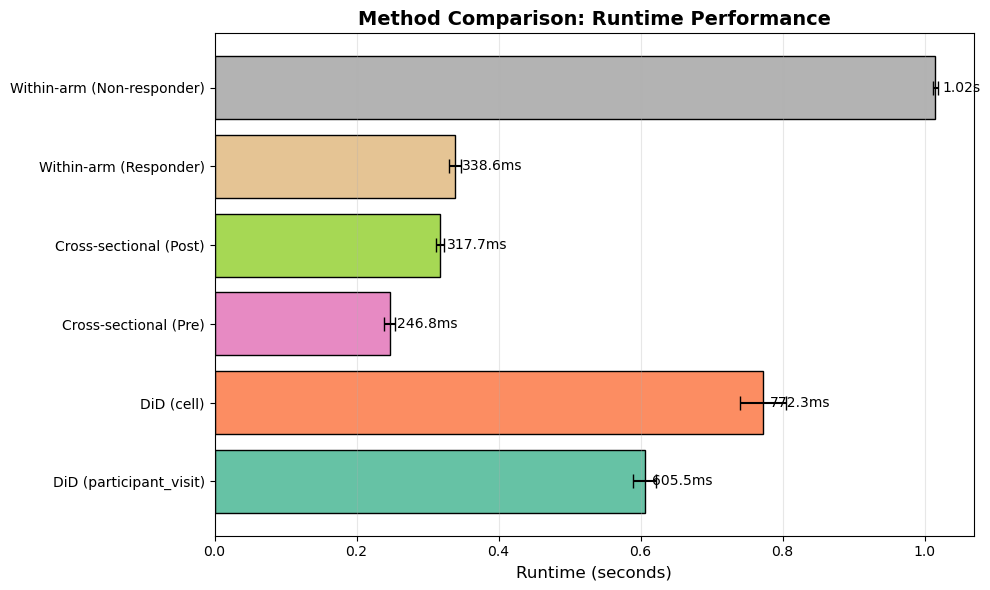

In [8]:
# =============================================================================
# METHOD COMPARISON BENCHMARK
# =============================================================================
print("=" * 70)
print("METHOD COMPARISON BENCHMARK")
print("=" * 70)
print("This compares: (1) DiD aggregation modes (participant_visit vs cell),")
print("(2) cross-sectional between-arm contrasts at each visit,")
print("and (3) within-arm paired changes. All use the same trial design and feature set.")



method_results = []

# Test different aggregation strategies
agg_modes = ["participant_visit", "cell"]
test_features = signature_cols if signature_cols else list(adata_paired.var_names[:100])

print("\nAggregation Mode Comparison:")
print("-" * 50)

for agg_mode in agg_modes:
    def run_agg_test(_agg=agg_mode):
        return st.did_table(
            adata_paired,
            features=test_features,
            design=design,
            visits=tuple(visits),
            aggregate=_agg,
            layer="log1p_tpm",
        )
    
    try:
        result, mean_time, std_time = timed_run(run_agg_test, n_repeats=N_BENCHMARK_REPEATS)
        n_results = len(result) if result is not None else 0
        method_results.append({
            'method': f'DiD ({agg_mode})',
            'mean_time': mean_time,
            'std_time': std_time,
            'n_results': n_results
        })
        print(f"  {agg_mode}: {format_time(mean_time)} ± {format_time(std_time)}")
    except Exception as e:
        print(f"  {agg_mode}: FAILED - {e}")
    gc.collect()

# Test cross-sectional comparisons
print("\nCross-sectional Comparison:")
print("-" * 50)

for v in visits:
    def run_cross(_v=v):
        return st.between_arm_comparison(
            adata_paired,
            visit=_v,
            features=test_features,
            design=design,
            aggregate="participant_visit",
            layer="log1p_tpm",
        )
    
    result, mean_time, std_time = timed_run(run_cross, n_repeats=N_BENCHMARK_REPEATS)
    method_results.append({
        'method': f'Cross-sectional ({v})',
        'mean_time': mean_time,
        'std_time': std_time,
        'n_results': len(result) if result is not None else 0
    })
    print(f"  {v}: {format_time(mean_time)} ± {format_time(std_time)}")
    gc.collect()

# Test within-arm comparisons
print("\nWithin-arm Comparison:")
print("-" * 50)

for arm in [design.arm_treated, design.arm_control]:
    if paired_by_response.get(arm, 0) < MIN_PAIRED_PER_ARM:
        print(f"  {arm}: SKIPPED (insufficient participants)")
        continue
    
    def run_within(_arm=arm):
        return st.within_arm_comparison(
            adata_paired,
            arm=_arm,
            features=test_features,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            layer="log1p_tpm",
        )
    
    result, mean_time, std_time = timed_run(run_within, n_repeats=N_BENCHMARK_REPEATS)
    method_results.append({
        'method': f'Within-arm ({arm})',
        'mean_time': mean_time,
        'std_time': std_time,
        'n_results': len(result) if result is not None else 0
    })
    print(f"  {arm}: {format_time(mean_time)} ± {format_time(std_time)}")
    gc.collect()

method_df = pd.DataFrame(method_results)
benchmark_results['timing']['methods'] = method_df

# Visualization — horizontal lollipop chart with error bars
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(method_df))
palette = plt.cm.Set2(np.linspace(0, 1, len(method_df)))

ax.hlines(y_pos, 0, method_df['mean_time'], color='#aaaaaa', linewidth=1.5)
ax.errorbar(method_df['mean_time'], y_pos,
            xerr=method_df['std_time'], fmt='none', ecolor='#555555',
            capsize=4, capthick=1.2, zorder=3)
ax.scatter(method_df['mean_time'], y_pos, c=palette, s=120,
           edgecolors='black', linewidths=0.8, zorder=4)

for i, (t, s) in enumerate(zip(method_df['mean_time'], method_df['std_time'])):
    ax.text(t + s + 0.02, i, format_time(t), va='center', fontsize=10, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(method_df['method'], fontsize=10)
ax.set_xlabel('Runtime (seconds)', fontsize=11)
ax.set_title('Method Comparison: Runtime', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.2)
ax.set_axisbelow(True)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

---
## 5. Memory Profiling & DiD Analysis

This section quantifies memory usage for key operations and then runs a genome‑wide DiD analysis on a fixed gene panel. The goal is to measure **resource footprint** and **end‑to‑end runtime** under realistic conditions.


In [9]:
# =============================================================================
# MEMORY PROFILING
# =============================================================================
print("=" * 70)
print("MEMORY PROFILING")
print("=" * 70)

memory_profile_results = []
did_results = None  # initialize before conditional assignment

# Profile signature DiD
if signature_cols and len(visits) == 2:
    def did_signatures():
        return st.did_table(
            adata_paired,
            features=signature_cols,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            layer="log1p_tpm",
        )
    
    did_results, peak_mb, current_mb = memory_profile(did_signatures)
    memory_profile_results.append({
        'operation': 'DiD (signatures)',
        'delta_mb': peak_mb,
        'current_mb': current_mb,
        'n_features': len(signature_cols)
    })
    print(f"DiD (signatures): RSS delta={peak_mb:.2f}MB, RSS current={current_mb:.2f}MB")

# Profile genome-wide DiD (subset)
test_gene_counts = [500, 1000, 2000]
print("\nGenome-wide DiD memory usage:")

for n_genes in test_gene_counts:
    if n_genes > adata_paired.n_vars:
        continue
    
    _test_genes_mem = list(adata_paired.var_names[:n_genes])
    
    def did_gw(genes=_test_genes_mem):
        return st.did_table(
            adata_paired,
            features=genes,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
            layer="log1p_tpm",
        )
    
    _, peak_mb, current_mb = memory_profile(did_gw)
    memory_profile_results.append({
        'operation': f'DiD ({n_genes} genes)',
        'delta_mb': peak_mb,
        'current_mb': current_mb,
        'n_features': n_genes
    })
    print(f"  {n_genes} genes: RSS delta={peak_mb:.2f}MB")
    del _test_genes_mem
    gc.collect()

memory_df = pd.DataFrame(memory_profile_results)
benchmark_results['memory'] = memory_df

# =============================================================================
# DID RESULTS ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("DID RESULTS: SIGNATURES")
print("=" * 70)

if did_results is not None and not did_results.empty:
    display(did_results[["feature", "beta_DiD", "se_DiD", "p_DiD", "FDR_DiD", "n_units"]].round(4))
    
    # Significance summary
    n_sig_nominal = (did_results['p_DiD'] < 0.05).sum()
    n_sig_fdr = (did_results['FDR_DiD'] < FDR_ALPHA).sum()
    print(f"\nSignificance summary:")
    print(f"  Nominal (p < 0.05): {n_sig_nominal}/{len(did_results)}")
    print(f"  FDR < {FDR_ALPHA}: {n_sig_fdr}/{len(did_results)}")

# Run full genome-wide benchmark
print("\n" + "=" * 70)
print("DID BENCHMARK: GENOME-WIDE")
print("=" * 70)

max_genes = min(2000, adata_paired.n_vars)
features_gw = list(adata_paired.var_names[:max_genes])

def did_genomewide():
    return st.did_table(
        adata_paired,
        features=features_gw,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        layer="log1p_tpm",
    )

res_gw, gw_time, gw_std = timed_run(did_genomewide, n_repeats=N_BENCHMARK_REPEATS)
benchmark_results['timing']['did_genomewide'] = gw_time

print(f"Genome-wide DiD ({max_genes} genes): {format_time(gw_time)} ± {format_time(gw_std)}")
print(f"Throughput: {max_genes/gw_time:.0f} genes/second")

if res_gw is not None and not res_gw.empty:
    print(f"\nTop 10 significant genes (by p-value):")
    display(res_gw.head(10)[["feature", "beta_DiD", "se_DiD", "p_DiD", "FDR_DiD", "n_units"]].round(4))

MEMORY PROFILING


DiD (signatures): RSS delta=0.00MB, RSS current=19353.12MB

Genome-wide DiD memory usage:


  500 genes: RSS delta=0.00MB


  1000 genes: RSS delta=1.84MB


  2000 genes: RSS delta=0.11MB

DID RESULTS: SIGNATURES


,feature,beta_DiD,se_DiD,p_DiD,FDR_DiD,n_units
0,sig_Activation,-2.0117,0.6568,0.0022,0.0110,10
1,sig_IFN_Response,-1.6544,1.8360,0.3675,0.7991,10
2,sig_Exhaustion,-0.7621,1.0886,0.4839,0.7991,10
3,sig_Memory,-0.8186,2.0637,0.6916,0.7991,10
4,sig_Cytotoxicity,-0.3820,1.5010,0.7991,0.7991,10



Significance summary:
  Nominal (p < 0.05): 1/5
  FDR < 0.25: 1/5

DID BENCHMARK: GENOME-WIDE


Genome-wide DiD (2000 genes): 4.78s ± 27.2ms
Throughput: 418 genes/second

Top 10 significant genes (by p-value):


,feature,beta_DiD,se_DiD,p_DiD,FDR_DiD,n_units
0,ABCC8,2.5994,0.5947,0.0000,0.0247,10
1,RBM7,-2.0196,0.4885,0.0000,0.0355,10
2,IP6K2,-1.6238,0.4469,0.0003,0.1856,10
3,PEX3,-2.0206,0.5947,0.0007,0.3389,10
4,AP3M2,-2.0088,0.6968,0.0039,0.9966,10
5,SLC4A7,-1.7360,0.6064,0.0042,0.9966,10
6,SPAST,-1.6535,0.5865,0.0048,0.9966,10
7,PRKCZ,2.0435,0.7251,0.0048,0.9966,10
8,C19orf60,-1.3039,0.4659,0.0051,0.9966,10
9,PIK3C3,-1.7934,0.6915,0.0095,0.9966,10


---
## 6. Statistical Validation

We validate statistical outputs with diagnostic panels:

- **P‑value histogram**: checks uniformity under the null. With only ~10 paired participants and real biological signal, perfect uniformity is not expected; deviations indicate a mix of true effects and low power rather than miscalibration.
- **QQ plot**: compares observed vs expected p‑values.
- **Effect size distribution**: verifies effect size spread and sign balance.
- **Volcano plot**: highlights effect sizes vs significance.
- **Memory usage**: summarizes peak memory by operation.
- **Signature forest plot**: shows DiD effects for signature‑level results.


STATISTICAL VALIDATION

1. P-value Distribution (quintiles):
   Expected: 0.20 in each quintile under null
   [0.0, 0.2): 0.090
   [0.2, 0.4): 0.181
   [0.4, 0.6): 0.268
   [0.6, 0.8): 0.259
   [0.8, 1.0): 0.201

2. Effect Size Distribution:
   Mean: -0.3445
   Std:  0.8019
   Min:  -2.4177
   Max:  2.5994

3. Sample Size Consistency:
   n_units values: [10]
   Expected: 10


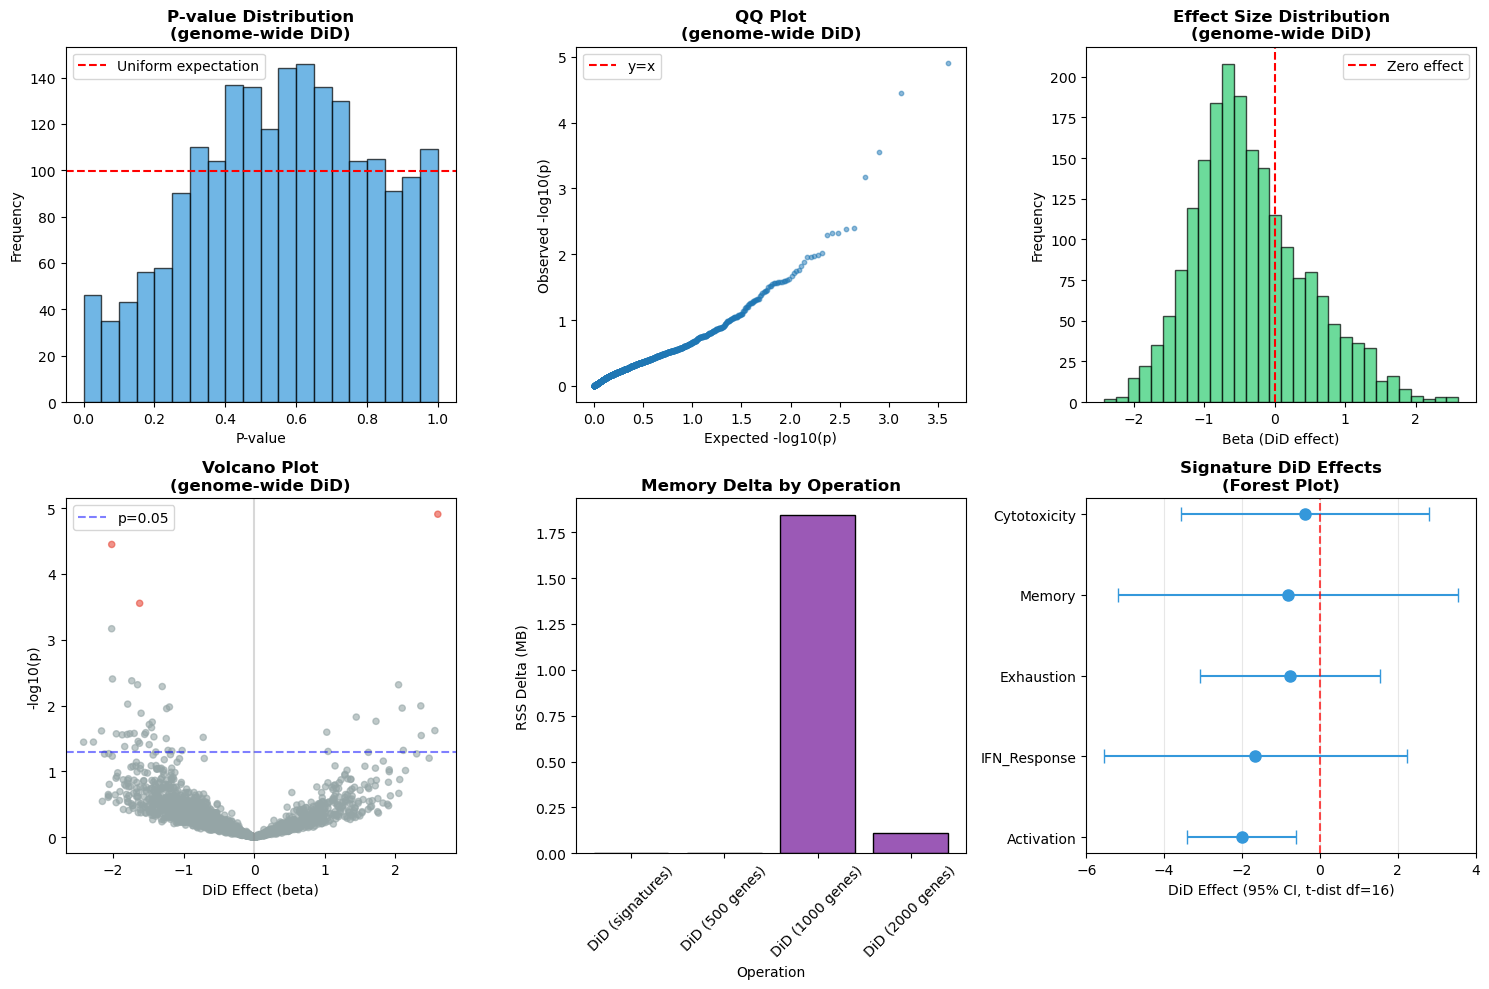

In [10]:
# =============================================================================
# STATISTICAL VALIDATION
# =============================================================================
print("=" * 70)
print("STATISTICAL VALIDATION")
print("=" * 70)

validation_results = {}

# 1. P-value Distribution Check
if res_gw is not None and not res_gw.empty:
    valid_p = res_gw['p_DiD'].dropna()
    
    # Under null, p-values should be uniformly distributed
    # Quick check: proportion in each quintile
    quintiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    observed_props = []
    for i in range(len(quintiles)-1):
        if i < len(quintiles) - 2:
            prop = ((valid_p >= quintiles[i]) & (valid_p < quintiles[i+1])).mean()
        else:
            prop = ((valid_p >= quintiles[i]) & (valid_p <= quintiles[i+1])).mean()
        observed_props.append(prop)
    
    validation_results['p_value_uniformity'] = observed_props
    
    print("\n1. P-value Distribution (quintiles):")
    print("   Expected: 0.20 in each quintile under null")
    for i, prop in enumerate(observed_props):
        print(f"   [{quintiles[i]:.1f}, {quintiles[i+1]:.1f}): {prop:.3f}")

# 2. Effect Size Distribution
if res_gw is not None and not res_gw.empty:
    valid_beta = res_gw['beta_DiD'].dropna()
    validation_results['beta_stats'] = {
        'mean': valid_beta.mean(),
        'std': valid_beta.std(),
        'median': valid_beta.median(),
        'min': valid_beta.min(),
        'max': valid_beta.max()
    }
    
    print("\n2. Effect Size Distribution:")
    print(f"   Mean: {valid_beta.mean():.4f}")
    print(f"   Std:  {valid_beta.std():.4f}")
    print(f"   Min:  {valid_beta.min():.4f}")
    print(f"   Max:  {valid_beta.max():.4f}")

# 3. Sample Size Consistency
if res_gw is not None and not res_gw.empty:
    n_units_values = res_gw['n_units'].unique()
    validation_results['n_units'] = list(n_units_values)
    
    print("\n3. Sample Size Consistency:")
    print(f"   n_units values: {sorted(n_units_values)}")
    print(f"   Expected: {N_VALID_PAIRED}")

benchmark_results['validation'] = validation_results

# =============================================================================
# VALIDATION VISUALIZATIONS
# =============================================================================
from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. P-value histogram
ax1 = axes[0, 0]
if res_gw is not None and not res_gw.empty:
    ax1.hist(res_gw['p_DiD'].dropna(), bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    ax1.axhline(len(res_gw['p_DiD'].dropna())/20, color='red', linestyle='--', label='Uniform expectation')
    ax1.set_xlabel('P-value')
    ax1.set_ylabel('Frequency')
    ax1.set_title('P-value Distribution\n(genome-wide DiD)', fontweight='bold')
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('P-value Distribution', fontweight='bold')

# 2. QQ plot
ax2 = axes[0, 1]
if res_gw is not None and not res_gw.empty:
    valid_p = res_gw['p_DiD'].dropna().sort_values()
    n_p = len(valid_p)
    expected_p = (np.arange(1, n_p + 1) - 0.5) / n_p  # Hazen plotting positions
    ax2.scatter(-np.log10(expected_p), -np.log10(valid_p), alpha=0.5, s=10)
    max_val = max(-np.log10(expected_p).max(), -np.log10(valid_p).max())
    ax2.plot([0, max_val], [0, max_val], 'r--', label='y=x')
    ax2.set_xlabel('Expected -log10(p)')
    ax2.set_ylabel('Observed -log10(p)')
    ax2.set_title('QQ Plot\n(genome-wide DiD)', fontweight='bold')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('QQ Plot', fontweight='bold')

# 3. Effect size distribution
ax3 = axes[0, 2]
if res_gw is not None and not res_gw.empty:
    ax3.hist(res_gw['beta_DiD'].dropna(), bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
    ax3.axvline(0, color='red', linestyle='--', label='Zero effect')
    ax3.set_xlabel('Beta (DiD effect)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Effect Size Distribution\n(genome-wide DiD)', fontweight='bold')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Effect Size Distribution', fontweight='bold')

# 4. Volcano plot (genome-wide)
ax4 = axes[1, 0]
if res_gw is not None and not res_gw.empty:
    valid_res = res_gw[res_gw['p_DiD'].notna() & res_gw['beta_DiD'].notna()]
    neg_log_p = -np.log10(valid_res['p_DiD'].clip(lower=1e-300))
    
    # Color by significance
    colors = ['#e74c3c' if fdr < FDR_ALPHA else '#95a5a6' 
              for fdr in valid_res['FDR_DiD'].fillna(1)]
    
    ax4.scatter(valid_res['beta_DiD'], neg_log_p, c=colors, alpha=0.6, s=20)
    ax4.axhline(-np.log10(0.05), color='blue', linestyle='--', alpha=0.5, label='p=0.05')
    ax4.axvline(0, color='gray', linestyle='-', alpha=0.3)
    ax4.set_xlabel('DiD Effect (beta)')
    ax4.set_ylabel('-log10(p)')
    ax4.set_title('Volcano Plot\n(genome-wide DiD)', fontweight='bold')
    ax4.legend()
else:
    ax4.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Volcano Plot', fontweight='bold')

# 5. Memory scaling — line plot for gene-scaling entries, dot for signature
ax5 = axes[1, 1]
if len(memory_df) > 0:
    col = 'delta_mb' if 'delta_mb' in memory_df.columns else 'peak_mb'
    # Separate signature entry from gene-scaling entries
    mask_genes = memory_df['n_features'].apply(lambda x: x >= 100)
    df_genes = memory_df[mask_genes].sort_values('n_features')
    df_sig = memory_df[~mask_genes]

    if len(df_genes) > 0:
        ax5.plot(df_genes['n_features'], df_genes[col], 'o-', color='#9b59b6',
                 linewidth=2, markersize=8, markeredgecolor='black', markeredgewidth=0.6,
                 label='Gene-count scaling')
    if len(df_sig) > 0:
        ax5.scatter(df_sig['n_features'], df_sig[col], marker='*', s=200,
                    color='#e6550d', edgecolors='black', linewidths=0.6, zorder=5,
                    label='Signatures only')
    ax5.set_xlabel('Number of Features')
    ax5.set_ylabel('RSS Delta (MB)')
    ax5.set_title('Memory by Feature Count', fontweight='bold')
    ax5.legend(fontsize=8, framealpha=0.9)
    ax5.grid(True, alpha=0.2)
else:
    ax5.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Memory Usage', fontweight='bold')

# 6. Signature-level results — forest plot with t-based CI
ax6 = axes[1, 2]
if did_results is not None and not did_results.empty:
    y_pos = range(len(did_results))
    # Use t-critical value for proper CI with small n
    # Note: df approximation for visualization only; statistical inference uses
    # the model's own SE/p-values which account for the full DiD specification.
    n_paired = did_results['n_units'].iloc[0] if 'n_units' in did_results.columns else N_VALID_PAIRED
    # DiD regression has 2*n_paired observations (pre+post per participant) and 4 parameters
    # (intercept, post, treated, post×treated), so df = 2*n_paired - 4
    df_resid = max(2 * n_paired - 4, 1)
    t_crit = sp_stats.t.ppf(0.975, df=df_resid)
    ax6.errorbar(did_results['beta_DiD'], y_pos, 
                 xerr=did_results['se_DiD'] * t_crit, 
                 fmt='o', capsize=5, color='#3498db', markersize=8)
    ax6.axvline(0, color='red', linestyle='--', alpha=0.7)
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(did_results['feature'].str.replace('sig_', ''))
    ax6.set_xlabel(f'DiD Effect (95% CI, t-dist df={df_resid})')
    ax6.set_title('Signature DiD Effects\n(Forest Plot)', fontweight='bold')
    ax6.grid(True, axis='x', alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Signature Effects', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. GSEA Benchmark

We benchmark gene set enrichment on expanded immune‑relevant gene sets. This evaluates both runtime and interpretability for pathway‑level summaries.


GSEA BENCHMARK

Gene Set Coverage:
  Cytotoxicity: 13/13 genes
  Exhaustion: 13/13 genes
  IFN_Response: 15/15 genes
  T_Cell_Activation: 11/11 genes
  Memory_T: 10/10 genes
  B_Cell_Response: 10/11 genes
  Antigen_Presentation: 9/9 genes
  Myeloid_Inflammation: 9/10 genes
  NK_Markers: 8/8 genes
  Chemokines: 9/10 genes
  Cell_Cycle: 10/10 genes
  Apoptosis: 9/9 genes
  Costimulation: 8/8 genes

Total gene sets for GSEA:
13


2026-02-25 15:04:39,031 [WARNING] Duplicated values found in preranked stats: 24.84% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



GSEA runtime: 1.9min
Gene sets per second: 0.1

GSEA Results:


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,IFN_Response,-0.732314,-1.759546,0.0,0.030137,0.019,15/15,26.79%,STAT1;MX1;MX2;IFITM1;ISG15;IFI44L;IFI44;IFI6;I...
1,prerank,B_Cell_Response,0.676856,1.565822,0.046569,0.077976,0.185,6/10,10.52%,IGHA1;IGHG1;IGHG2;CD79B;IGKC;CD79A
2,prerank,Chemokines,-0.671906,-1.411026,0.079038,0.448467,0.453,9/9,32.82%,CCL3;CXCL11;CCL2;CXCL9;CXCL10;CXCL2;CCL4;CCL5;...
3,prerank,Exhaustion,-0.607116,-1.401916,0.092257,0.318113,0.473,10/13,33.25%,IRF4;CTLA4;ICOS;EOMES;HAVCR2;LAYN;ENTPD1;LAG3;...
4,prerank,Antigen_Presentation,-0.655176,-1.366071,0.123311,0.294912,0.551,7/9,27.46%,B2M;HLA-A;HLA-C;HLA-DPB1;CD74;HLA-DPA1;HLA-B
5,prerank,Apoptosis,-0.645602,-1.338906,0.13468,0.279843,0.614,5/9,25.18%,FAS;TNFRSF10B;CASP3;FASLG;BID
6,prerank,T_Cell_Activation,-0.607957,-1.3337,0.149485,0.238943,0.622,8/11,27.76%,IL2RA;CD38;ICOS;CD28;TNFRSF9;IFNG;CD27;CD69
7,prerank,Cell_Cycle,-0.616866,-1.322096,0.123457,0.217314,0.644,8/10,34.89%,MCM6;PCNA;MCM5;CCNB1;TYMS;CCNB2;UBE2C;TOP2A
8,prerank,Costimulation,-0.624324,-1.249148,0.198962,0.276794,0.775,4/8,17.33%,TNFSF9;ICOS;CD28;TNFRSF9
9,prerank,Myeloid_Inflammation,-0.578058,-1.205582,0.239796,0.294832,0.853,9/9,42.21%,IL1B;S100A8;S100A9;LYZ;LGALS3;CTSD;LILRB1;VCAN...


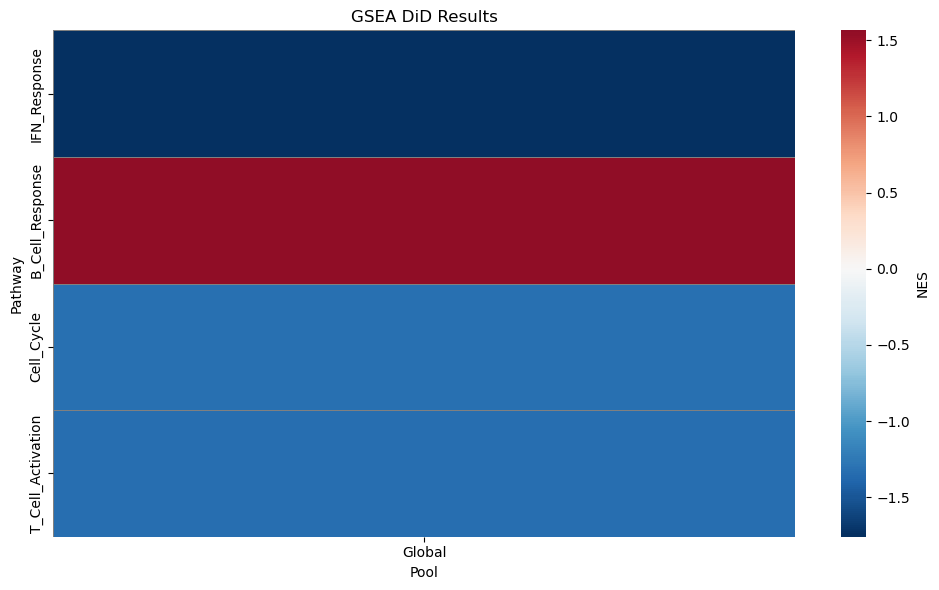

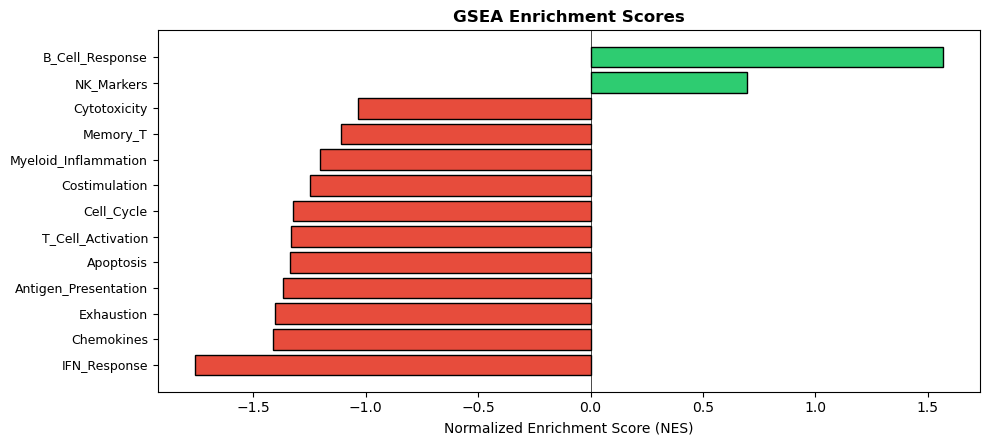

4550

In [11]:
# =============================================================================
# GSEA GENE SETS
# =============================================================================
print("=" * 70)
print("GSEA BENCHMARK")
print("=" * 70)

expanded_sets = {
    "Cytotoxicity": ["GZMB", "GZMA", "GZMH", "GZMK", "PRF1", "GNLY", "NKG7", "IFNG", "KLRD1", "KLRB1", "KLRK1", "FASLG", "CTSW"],
    "Exhaustion": ["PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4", "ENTPD1", "TOX", "CXCL13", "EOMES", "BATF", "IRF4", "ICOS", "LAYN"],
    "IFN_Response": ["ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "MX2", "STAT1", "OAS1", "IRF7", "IFITM1", "IFITM3", "IFI44", "IFI44L", "OAS2"],
    "T_Cell_Activation": ["CD69", "CD38", "HLA-DRA", "ICOS", "IL2RA", "TNFRSF9", "CD27", "CD28", "TNFRSF4", "CD40LG", "IFNG"],
    "Memory_T": ["IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28", "BCL2", "LTB", "MALAT1"],
    "B_Cell_Response": ["CD79A", "CD79B", "MS4A1", "MZB1", "XBP1", "JCHAIN", "IGHG1", "IGHG2", "IGHA1", "IGKC", "CD74"],
    "Antigen_Presentation": ["HLA-DRA", "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "CD74", "HLA-A", "HLA-B", "HLA-C", "B2M"],
    "Myeloid_Inflammation": ["S100A8", "S100A9", "LYZ", "VCAN", "IL1B", "CXCL8", "CTSD", "LGALS3", "FCGR3A", "LILRB1"],
    "NK_Markers": ["NKG7", "KLRD1", "KLRB1", "GNLY", "PRF1", "TRAC", "FCGR3A", "TYROBP"],
    "Chemokines": ["CCL2", "CCL3", "CCL4", "CCL5", "CXCL9", "CXCL10", "CXCL11", "CXCL8", "CXCL2", "CXCL3"],
    "Cell_Cycle": ["MKI67", "TOP2A", "TYMS", "MCM5", "MCM6", "MCM7", "PCNA", "UBE2C", "CCNB1", "CCNB2"],
    "Apoptosis": ["BAX", "BCL2", "CASP3", "CASP8", "FAS", "FASLG", "BID", "BCL2L1", "TNFRSF10B"],
    "Costimulation": ["CD27", "CD28", "TNFRSF4", "TNFRSF9", "ICOS", "CD40", "CD40LG", "TNFSF9"],
}

gene_sets = {}
print("\nGene Set Coverage:")
for k, genes in expanded_sets.items():
    present = [g for g in genes if g in adata_paired.var_names]
    if len(present) >= MIN_GENES_FOR_SCORE:
        gene_sets[k] = present
        print(f"  {k}: {len(present)}/{len(genes)} genes")

print("\nTotal gene sets for GSEA:")
print(len(gene_sets))

# =============================================================================
# RUN GSEA WITH TIMING (single run — GSEA uses internal permutations so
# repeated benchmarking is redundant and very slow)
# =============================================================================
if gene_sets:
    def run_gsea():
        return st.run_gsea_did_multi(
            adata_paired,
            gene_sets={"Custom": gene_sets},
            design=design,
            visits=tuple(visits),
            min_size=MIN_GENES_FOR_SCORE,
        )

    gsea_res, gsea_time, gsea_std = timed_run(run_gsea, n_repeats=1)
    gsea_res = gsea_res.get("Custom", pd.DataFrame())
    benchmark_results["timing"]["gsea_did"] = gsea_time

    print("\nGSEA runtime:", format_time(gsea_time))
    print("Gene sets per second:", f"{len(gene_sets)/gsea_time:.1f}")

    if gsea_res is not None and not gsea_res.empty:
        print("\nGSEA Results:")
        display(gsea_res.round(4))

        # Heatmap
        try:
            st.plot_gsea_heatmap(
                gsea_res,
                title="GSEA DiD Results",
                figsize=(10, 6),
                fdr_thresh=0.25,
                top_n=20,
            )
        except Exception as e:
            print(f"Heatmap error: {e}")

        # Bar plot of NES
        fig, ax2 = plt.subplots(figsize=(10, max(4, 0.35 * len(gsea_res))))
        if "NES" in gsea_res.columns:
            sorted_res = gsea_res.sort_values("NES")
            labels = sorted_res["Term"] if "Term" in sorted_res.columns else sorted_res.index
            colors = ["#e74c3c" if nes < 0 else "#2ecc71" for nes in sorted_res["NES"]]
            ax2.barh(labels, sorted_res["NES"], color=colors, edgecolor="black")
            ax2.axvline(0, color="black", linewidth=0.5)
            ax2.set_xlabel("Normalized Enrichment Score (NES)")
            ax2.set_title("GSEA Enrichment Scores", fontweight="bold")
            ax2.tick_params(axis="y", labelsize=9)
        else:
            ax2.text(0.5, 0.5, "NES not available", ha="center", va="center", transform=ax2.transAxes)
        plt.tight_layout()
        plt.show()
else:
    print("No gene sets available for GSEA.")

gc.collect()

### Workflow API Example

Here we run DiD using the fluent workflow API with a DiDConfig object.

In [12]:
if signature_cols:
    cfg = st.DiDConfig(aggregate='participant_visit', standardize=True, use_bootstrap=False, layer="log1p_tpm")
    wf_res = (
        st.workflow(adata_paired)
        .did_table(features=signature_cols[:1], design=design, visits=tuple(visits), config=cfg)
        .result()
    )
    display(wf_res)

,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,resid_sd,feature,FDR_DiD
0,-0.382015,1.501016,0.799106,0.366814,0.631812,10,18.570902,sig_Cytotoxicity,0.799106
